Index:
- geospatial visualisations of Index/GDP/SIMFONI
- write documentation (codes)

In [101]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def get_project_root():
    return Path().resolve().parent

index = pd.read_csv(get_project_root() / "data" / "processed" / "wide_validation_index.csv")

shp_path = (get_project_root()/ "data"/ "shapefiles"/ "idn_admbnda_adm2_bps_20200401.shp")
polygons = gpd.read_file(shp_path)

boundaries_path = (get_project_root()/ "data"/ "shapefiles"/ 'idn_adminboundaries_tabulardata(ADM2).csv')
boundaries = pd.read_csv(boundaries_path)

boundaries = polygons.merge(
    boundaries,
    left_index=True,
    right_index=True,
    how="left"
)

In [102]:
index.head()

,fullname,year,policy_version,1.1,1.2,1.3,1.4,1.5,1.6,1.7,...,scope_of_violence,institutional_mechanism,specialised_support_services,primary_prevention,stakeholder_engagement,intersectional_approach,budget_funding_sources,coverage_subindex,implementation_subindex,quality_index
0,ACEH ACEH BARAT,2004,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ACEH ACEH BARAT,2005,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ACEH ACEH BARAT,2006,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ACEH ACEH BARAT,2007,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ACEH ACEH BARAT,2008,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [103]:
boundaries[['geometry', 'ADM2_EN', 'ADM2_PCODE']]

,geometry,ADM2_EN,ADM2_PCODE
0,"POLYGON ((96.26836 4.768, 96.26822 4.7625, 96....",Aceh Barat,ID1107
1,"MULTIPOLYGON (((96.80559 3.71758, 96.80444 3.7...",Aceh Barat Daya,ID1112
2,"MULTIPOLYGON (((95.20544 5.28072, 95.20563 5.2...",Aceh Besar,ID1108
3,"MULTIPOLYGON (((95.58431 4.61495, 95.58379 4.6...",Aceh Jaya,ID1116
4,"MULTIPOLYGON (((97.59461 2.80777, 97.59365 2.8...",Aceh Selatan,ID1103
...,...,...,...
517,"POLYGON ((104.92793 -4.19234, 104.92823 -4.192...",Way Kanan,ID1807
518,"POLYGON ((111.18204 -7.71237, 111.18242 -7.712...",Wonogiri,ID3312
519,"POLYGON ((109.93 -7.19465, 109.93017 -7.19496,...",Wonosobo,ID3307
520,"POLYGON ((139.96223 -3.6098, 139.96314 -3.6099...",Yahukimo,ID9416


In [104]:
index.columns

Index(['fullname', 'year', 'policy_version', '1.1', '1.2', '1.3', '1.4', '1.5',
       '1.6', '1.7', '1.8', '1.9', '1.10', '2.1', '2.2', '2.3', '2.4', '2.5',
       '2.6', '3.1', '3.2', '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9',
       '3.10', '4.1', '4.2', '4.3', '4.4', '5.1', '5.2', '5.3', '5.4', '5.5',
       '5.6', '5.7', '5.8', '6.1', '6.2', '6.3', '6.4', '6.5', '6.6', '6.7',
       '6.8', '6.9', '6.10', '6.11', '6.12', '6.13', '7.1', '7.2', '7.3',
       '7.4', '7.5', 'adoption_isu', 'vaw_reported_cases', 'gdp',
       'policy_change', 'has_policy', 'filename', 'value_kab', 'ADM2_PCODE',
       'scope_of_violence', 'institutional_mechanism',
       'specialised_support_services', 'primary_prevention',
       'stakeholder_engagement', 'intersectional_approach',
       'budget_funding_sources', 'coverage_subindex',
       'implementation_subindex', 'quality_index'],
      dtype='str')

In [105]:
df = index[['ADM2_PCODE', 'quality_index', 'year', 'fullname', 'vaw_reported_cases', 'gdp']]#.dropna()
df = df[df['year']==2025]
df

,ADM2_PCODE,quality_index,year,fullname,vaw_reported_cases,gdp
21,ID1107,NaN,2025,ACEH ACEH BARAT,31.0,14829.0
43,ID1112,NaN,2025,ACEH ACEH BARAT DAYA,7.0,5788.0
65,ID1108,NaN,2025,ACEH ACEH BESAR,11.0,19555.0
87,ID1116,NaN,2025,ACEH ACEH JAYA,9.0,3879.0
109,ID1103,NaN,2025,ACEH ACEH SELATAN,4.0,8035.0
...,...,...,...,...,...,...
11109,ID1203,NaN,2025,SUMATERA UTARA TAPANULI SELATAN,12.0,23638.0
11131,ID1204,NaN,2025,SUMATERA UTARA TAPANULI TENGAH,8.0,14560.0
11153,ID1205,NaN,2025,SUMATERA UTARA TAPANULI UTARA,6.0,12052.0
11175,ID1274,NaN,2025,SUMATERA UTARA TEBING TINGGI KOTA,28.0,8265.0


In [106]:
df = df.merge(
    boundaries[['geometry', 'ADM2_EN', 'ADM2_PCODE']],
    on='ADM2_PCODE',
    how='left'
)
df

,ADM2_PCODE,quality_index,year,fullname,vaw_reported_cases,gdp,geometry,ADM2_EN
0,ID1107,NaN,2025,ACEH ACEH BARAT,31.0,14829.0,"POLYGON ((96.26836 4.768, 96.26822 4.7625, 96....",Aceh Barat
1,ID1112,NaN,2025,ACEH ACEH BARAT DAYA,7.0,5788.0,"MULTIPOLYGON (((96.80559 3.71758, 96.80444 3.7...",Aceh Barat Daya
2,ID1108,NaN,2025,ACEH ACEH BESAR,11.0,19555.0,"MULTIPOLYGON (((95.20544 5.28072, 95.20563 5.2...",Aceh Besar
3,ID1116,NaN,2025,ACEH ACEH JAYA,9.0,3879.0,"MULTIPOLYGON (((95.58431 4.61495, 95.58379 4.6...",Aceh Jaya
4,ID1103,NaN,2025,ACEH ACEH SELATAN,4.0,8035.0,"MULTIPOLYGON (((97.59461 2.80777, 97.59365 2.8...",Aceh Selatan
...,...,...,...,...,...,...,...,...
504,ID1203,NaN,2025,SUMATERA UTARA TAPANULI SELATAN,12.0,23638.0,"MULTIPOLYGON (((99.32404 1.30954, 99.32438 1.3...",Tapanuli Selatan
505,ID1204,NaN,2025,SUMATERA UTARA TAPANULI TENGAH,8.0,14560.0,"MULTIPOLYGON (((98.48957 1.68841, 98.48957 1.6...",Tapanuli Tengah
506,ID1205,NaN,2025,SUMATERA UTARA TAPANULI UTARA,6.0,12052.0,"MULTIPOLYGON (((99.06054 1.6994, 99.06042 1.69...",Tapanuli Utara
507,ID1274,NaN,2025,SUMATERA UTARA TEBING TINGGI KOTA,28.0,8265.0,"POLYGON ((99.17138 3.37627, 99.176 3.37209, 99...",Kota Tebing Tinggi


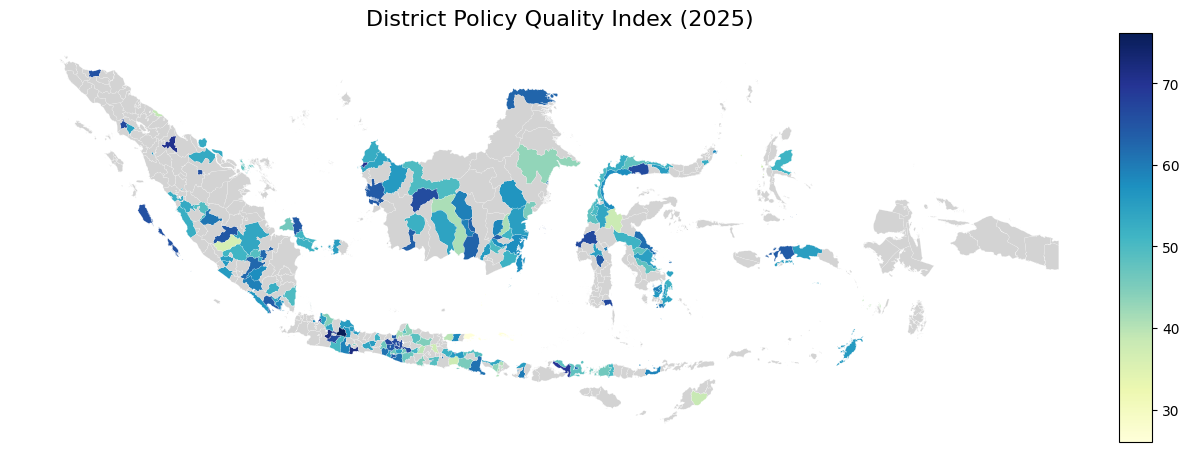

In [107]:
gdf = gpd.GeoDataFrame(
    df,
    geometry="geometry",
    crs="EPSG:4326"  # adjust if your boundaries use a different CRS
)

fig, ax = plt.subplots(figsize=(12, 8))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

gdf.plot(
    column="quality_index",
    cmap="YlGnBu",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    cax=cax,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "No data",
    },
    ax=ax,
)

ax.set_title("District Policy Quality Index (2025)", fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.show()

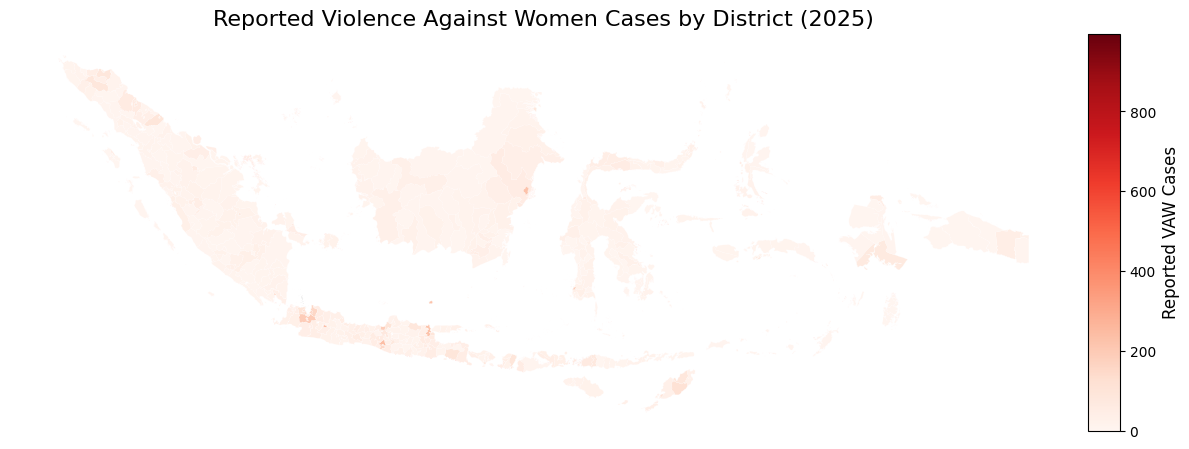

In [108]:
# TODO: weight by population

fig, ax = plt.subplots(figsize=(12, 8))

divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="3%", pad=0.1)

gdf.plot(
    column="vaw_reported_cases",
    cmap="Reds",
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    cax=cax,
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "No data",
    },
    ax=ax,
)

cax.set_ylabel("Reported VAW Cases", fontsize=12)

ax.set_title("Reported Violence Against Women Cases by District (2025)", fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.show()

<Axes: >

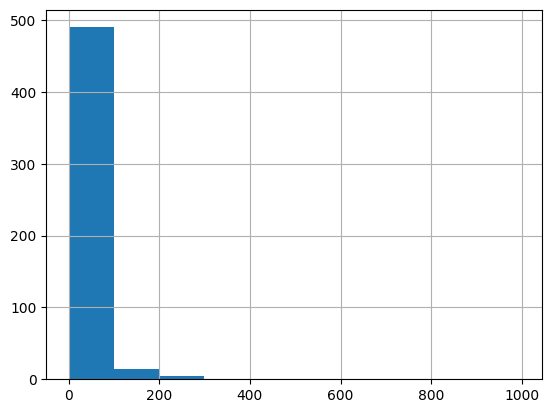

In [109]:
df["vaw_reported_cases"].hist()

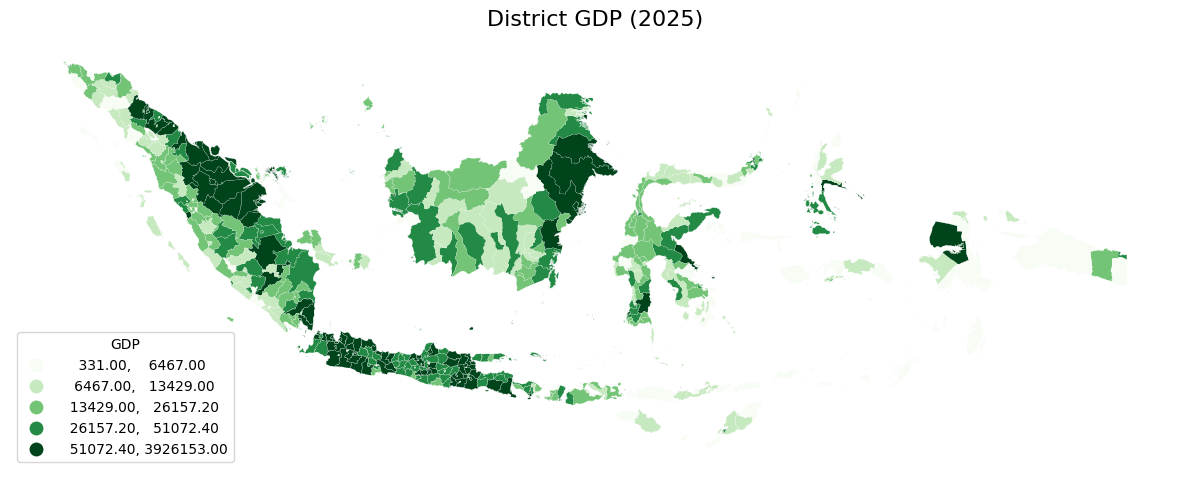

In [115]:
fig, ax = plt.subplots(figsize=(12, 8))

gdf.plot(
    column="gdp",
    cmap="Greens",
    scheme="quantiles",
    k=5,
    linewidth=0.1,
    edgecolor="white",
    legend=True,
    legend_kwds={
        "title": "GDP",
        "loc": "lower left",
        "frameon": True,
    },
    missing_kwds={
        "color": "lightgrey",
        "edgecolor": "white",
        "label": "No data",
    },
    ax=ax,
)

ax.set_title("District GDP (2025)", fontsize=16)
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [111]:
df

,ADM2_PCODE,quality_index,year,fullname,vaw_reported_cases,gdp,geometry,ADM2_EN
0,ID1107,NaN,2025,ACEH ACEH BARAT,31.0,14829.0,"POLYGON ((96.26836 4.768, 96.26822 4.7625, 96....",Aceh Barat
1,ID1112,NaN,2025,ACEH ACEH BARAT DAYA,7.0,5788.0,"MULTIPOLYGON (((96.80559 3.71758, 96.80444 3.7...",Aceh Barat Daya
2,ID1108,NaN,2025,ACEH ACEH BESAR,11.0,19555.0,"MULTIPOLYGON (((95.20544 5.28072, 95.20563 5.2...",Aceh Besar
3,ID1116,NaN,2025,ACEH ACEH JAYA,9.0,3879.0,"MULTIPOLYGON (((95.58431 4.61495, 95.58379 4.6...",Aceh Jaya
4,ID1103,NaN,2025,ACEH ACEH SELATAN,4.0,8035.0,"MULTIPOLYGON (((97.59461 2.80777, 97.59365 2.8...",Aceh Selatan
...,...,...,...,...,...,...,...,...
504,ID1203,NaN,2025,SUMATERA UTARA TAPANULI SELATAN,12.0,23638.0,"MULTIPOLYGON (((99.32404 1.30954, 99.32438 1.3...",Tapanuli Selatan
505,ID1204,NaN,2025,SUMATERA UTARA TAPANULI TENGAH,8.0,14560.0,"MULTIPOLYGON (((98.48957 1.68841, 98.48957 1.6...",Tapanuli Tengah
506,ID1205,NaN,2025,SUMATERA UTARA TAPANULI UTARA,6.0,12052.0,"MULTIPOLYGON (((99.06054 1.6994, 99.06042 1.69...",Tapanuli Utara
507,ID1274,NaN,2025,SUMATERA UTARA TEBING TINGGI KOTA,28.0,8265.0,"POLYGON ((99.17138 3.37627, 99.176 3.37209, 99...",Kota Tebing Tinggi


In [112]:

missing = df[df['geometry'].isna()] # in dataframe but NOT in shapefile
print(f"Missing geometries: {len(missing)}")
print(missing['ADM2_PCODE'].unique())

Missing geometries: 26
<ArrowStringArray>
['ID9204', 'ID9201', 'ID9202', 'ID9271', 'ID9203', 'ID9205', 'ID9702',
 'ID9703', 'ID9705', 'ID9701', 'ID9708', 'ID9704', 'ID9707', 'ID9706',
 'ID9504', 'ID9502', 'ID9503', 'ID9501', 'ID9603', 'ID9602', 'ID9606',
 'ID9601', 'ID9604', 'ID9605', 'ID9607', 'ID9608']
Length: 26, dtype: str


they are in master (2024), are these new since 2020?

PAPUA BARAT DAYA,92,R102,SORONG,9202,2,PAPUA BARAT DAYA SORONG

PAPUA BARAT DAYA,92,R102,TAMBRAUW,9205,5,PAPUA BARAT DAYA TAMBRAUW